# Traffic Case Study

The case study follows a rigorous four-stage Actuarial Causal Inference cycle designed to move from raw observational data to actionable interventional logic:

1. **Data Overview & Pre-processing**: We begin by exploring the (traffic addicent dataset)[https://www.kaggle.com/datasets/denkuznetz/traffic-accident-prediction], containing information on the occurrence and severity of traffic accidents based on various factors affecting road conditions, driver behavior, and traffic situations. We perform feature engineering to map categorical severity into a numeric proxy for loss and conducting positivity checks to ensure sufficient covariate overlap between groups.

2. **Identification** (The Causal Model): We use Directed Acyclic Graphs (DAGs) to encode domain knowledge and identify "backdoor paths"—such as `Weather` or `Time_of_Day`—ensuring we satisfy the Conditional Exchangeability assumption required to isolate true causal effects.
    - `Road_Lighting` (Scenario A) | W 
    - `Speed_Limits` (Scenario B) | W

3. **Inference & CATE Estimation**: We employ Double Machine Learning (DML) approaches, i.e., causal forests, to isolate the causal impact of two possible interventions on loss severity: 
    - `Road_Lighting` (Scenario A) | W 
    - `Speed_Limits` (Scenario B) | W

4. **Actuarial Interpretation & Prescriptive Action**: Finally, we translate these findings into actionable recommendations, demonstrating how actuaries can transition from a historical role of risk measurers to a proactive role in intelligent risk management by prescribing targeted and cost effective safety interventions.



#https://www.kaggle.com/datasets/khushikyad001/india-road-accident-dataset-predictive-analysis
#https://www.kaggle.com/datasets/oktayrdeki/traffic-accidents

In [1]:
# Install libraries for Causal Inference and Visualization
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import shap
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from econml.dml import CausalForestDML
from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter
import networkx as nx

# Suppress specific warnings globally
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Import helper functions from utils
from utils import draw_causal_dag, extract_tree_rules, extract_tree_rules_native, get_pdp_speed

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from ridgeplot import ridgeplot
import plotly.graph_objects as go
import plotly
sns.set_theme(style="whitegrid")
plotly.offline.init_notebook_mode(connected=True)

C:\Users\Theresa\.conda\envs\causalinference\Lib\site-packages\networkx\utils\backends.py:102: RuntimeWarning: networkx backend defined more than once: nx_loopback
  backends = _get_backends("networkx.backends")


## 1. Data Overview & Pre-Processing
### Overview

In [2]:
df = pd.read_csv(os.path.join('..', 'data', 'dataset_traffic_accident_prediction1.csv'))

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head(10)

Dataset shape: (840, 14)

First few rows:


,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident
0,Rainy,City Road,Morning,1.0,100.0,5.0,0.0,NaN,Wet,Car,51.0,48.0,Artificial Light,0.0
1,Clear,Rural Road,Night,NaN,120.0,3.0,0.0,Moderate,Wet,Truck,49.0,43.0,Artificial Light,0.0
2,Rainy,Highway,Evening,1.0,60.0,4.0,0.0,Low,Icy,Car,54.0,52.0,Artificial Light,0.0
3,Clear,City Road,Afternoon,2.0,60.0,3.0,0.0,Low,Under Construction,Bus,34.0,31.0,Daylight,0.0
4,Rainy,Highway,Morning,1.0,195.0,11.0,0.0,Low,Dry,Car,62.0,55.0,Artificial Light,1.0
5,Clear,Rural Road,Night,0.0,120.0,3.0,0.0,Moderate,NaN,Truck,49.0,43.0,Artificial Light,0.0
6,Foggy,Highway,Afternoon,0.0,60.0,4.0,0.0,Low,Dry,Truck,27.0,26.0,Daylight,1.0
7,Rainy,City Road,Afternoon,0.0,60.0,4.0,0.0,Low,Dry,Car,29.0,22.0,Artificial Light,1.0
8,Stormy,Highway,Morning,1.0,60.0,2.0,0.0,High,Icy,Car,38.0,29.0,Artificial Light,0.0
9,Rainy,City Road,Afternoon,2.0,30.0,2.0,0.0,Low,Dry,Truck,50.0,48.0,Artificial Light,0.0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Weather               798 non-null    object 
 1   Road_Type             798 non-null    object 
 2   Time_of_Day           798 non-null    object 
 3   Traffic_Density       798 non-null    float64
 4   Speed_Limit           798 non-null    float64
 5   Number_of_Vehicles    798 non-null    float64
 6   Driver_Alcohol        798 non-null    float64
 7   Accident_Severity     798 non-null    object 
 8   Road_Condition        798 non-null    object 
 9   Vehicle_Type          798 non-null    object 
 10  Driver_Age            798 non-null    float64
 11  Driver_Experience     798 non-null    float64
 12  Road_Light_Condition  798 non-null    object 
 13  Accident              798 non-null    float64
dtypes: float64(7), object(7)
memory usage: 92.0+ KB


In [4]:
density_map = {0: 'Low', 1: 'Moderate', 2: 'High'}
df['Traffic_Density'] = df['Traffic_Density'].map(density_map)
categorical_variables = ['Weather', 'Road_Type', 'Road_Condition', 'Traffic_Density', 'Time_of_Day', 'Road_Light_Condition', 'Traffic_Density']
for col in categorical_variables:
    print(f"\n{col} unique values:")
    print(df[col].unique())
    df[col] = df[col].astype('category')




Weather unique values:
['Rainy' 'Clear' 'Foggy' 'Stormy' nan 'Snowy']

Road_Type unique values:
['City Road' 'Rural Road' 'Highway' nan 'Mountain Road']

Road_Condition unique values:
['Wet' 'Icy' 'Under Construction' 'Dry' nan]

Traffic_Density unique values:
['Moderate' nan 'High' 'Low']

Time_of_Day unique values:
['Morning' 'Night' 'Evening' 'Afternoon' nan]

Road_Light_Condition unique values:
['Artificial Light' 'Daylight' 'No Light' nan]

Traffic_Density unique values:
['Moderate', NaN, 'High', 'Low']
Categories (3, object): ['High', 'Low', 'Moderate']


### Pre-Processing

We pre-process the raw observational data for causal analysis by defining actuarial outcomes and interventional treatments and risk factors as well as confounders:

* Defining the Outcome (Loss Proxy): We map the categorical `Accident_Severity` labels to a numeric scale where Low = 1, Moderate = 2, and High = 3. In an actuarial context, this serves as our proxy for Loss Amount, allowing us to quantify how specific treatments change the expected severity of a traffic accident claim.
* Defining the Treatments: 
    * `Road Lighting` (Scenario A): We isolate the causal effect of infrastructure in the form of road lightning by creating a binary treatment comparing "Artificial Light" against "No Light". By explicitly excluding "Daylight," we focus the analysis on the potential safety gains of installing lighting in otherwise dark areas.
    * `Speed Limit` (Scenario B): We define a continuous treatment of "Speed Limit". We can identify the "risk gradient" of speed, calculating exactly how much each additional km/h contributes to accident severity under varying conditions. 
* Data Quality and Cleaning: We perform targeted row-wise deletion to remove missing values specifically from the outcome and the confounders identified in our DAGs (such as `Weather`, `Time of Day`, and `Traffic Density`). This ensures that our identification strategy fulfills the causal modelling assumptions, as the model requires complete data on these variables to effectively "block" backdoor paths and isolate the true treatment effect.

In [5]:
# 1. Define Outcome Variable as Proxy for Loss Severity
severity_map = {'Low': 1, 'Moderate': 2, 'High': 3}
df['Loss'] = df['Accident_Severity'].map(severity_map)

# 2. Define Treatment Variables
## Road Lighting
df_light = df[df['Road_Light_Condition'].isin(['Artificial Light', 'No Light'])].copy()
df_light['Treatment_Light'] = (df_light['Road_Light_Condition'] == 'Artificial Light').astype(int)
df_light = df_light.dropna(subset=['Loss', 'Driver_Experience', 'Time_of_Day', 'Weather', 'Traffic_Density']).copy()

## Speed
df['Treatment_Speed'] = df['Speed_Limit'].astype(float)
df_speed = df.dropna(subset=['Loss', 'Treatment_Speed', 'Road_Condition', 'Weather', 'Road_Type', 'Traffic_Density']).copy()

## 3. Identification


### Scenario A: The `Road Lighting` Causal Path
In the graph below, `Time_of_Day` is a Confounder. If we don't adjust for it, we might mistake the high risk of "Night" for a failure of "Lighting."

Let $T \in \{0, 1\}$ represent the treatment variable (Artificial Light present vs. No Light) and $Y$ represent the observed Loss Severity. We adjust for the vector $\mathbf{X}$ to ensure that we are comparing "comparable" driving environments, satisfying the **Conditional Exchangeability** requirement.

| Variable ($X_i$) | Influence on Assignment ($X \rightarrow T$) | Influence on Loss ($X \rightarrow Y$) | Actuarial Rationale |
| :--- | :--- | :--- | :--- |
| **Time of Day** | $P(T=1 \mid \text{Afternoon}) \neq P(T=1 \mid \text{Night})$ | $\mathbb{E}[Y \mid \text{Night}] > \mathbb{E}[Y \mid \text{Day}]$ | **Temporal Confounding:** Artificial lights are logically associated with low-light hours. Failure to control for Time of Day would lead to a "spurious correlation" where lights appear to increase risk simply because they are used when visibility is naturally at its lowest. |
| **Traffic Density** | $\text{Cov}(T, \text{Density}) > 0$ | $\mathbb{E}[Y \mid \text{High Density}] \neq \mu_Y$ | **Urban Bias:** Public infrastructure (lighting) is concentrated in high-density areas. These zones have higher frequency and unique severity patterns (e.g., multi-vehicle vs. single-vehicle). |
| **Weather** | $T = f(\text{Weather}, \dots)$ | $\frac{\partial \mathbb{E}[Y]}{\partial \text{Visibility}} < 0$ | **Visibility Hazard:** Fog or Heavy Rain may trigger automated lighting systems. Since weather is a primary driver of claim severity, it must be blocked to isolate the "pure" luminosity effect of the treatment. |
| **Driver Experience** | $\text{Independent of } T$ | $\frac{\partial \mathbb{E}[Y]}{\partial \text{Exp}} < 0$ | **Effect Modifier:** While experience doesn't dictate if a road has lights, it dictates how the driver *responds* to the light. This is the key to identifying our Heterogeneous Treatment Effect (HTE). |



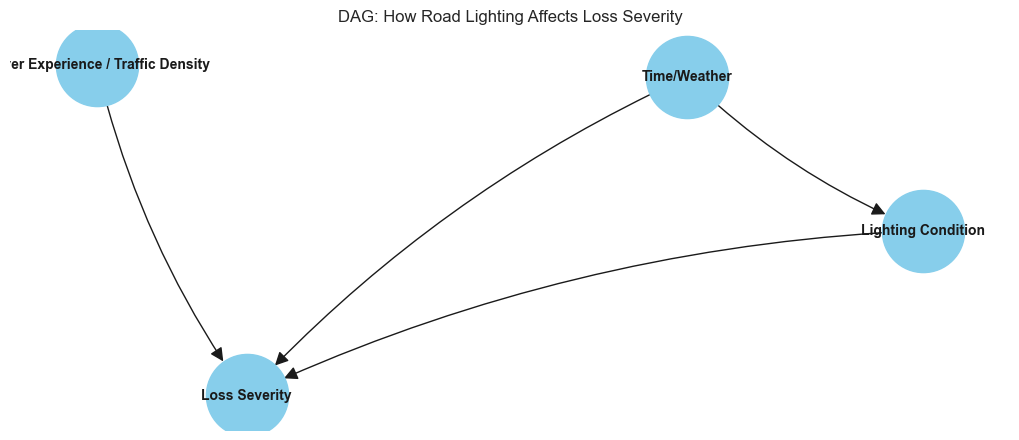

In [6]:
draw_causal_dag([
    ('Time/Weather', 'Lighting Condition'), # Confounding: Busy areas get lights
    ('Time/Weather', 'Loss Severity'),      # Environment impacts risk
    ('Lighting Condition', 'Loss Severity'),        # THE CAUSAL EFFECT
    ('Driver Experience / Traffic Density', 'Loss Severity')          # The Moderator
], "DAG: How Road Lighting Affects Loss Severity")

### Scenario B: Identification of the `Speed Limit` Causal Path
In this scenario, we visualize how road safety engineering and environmental conditions create a complex web of "Selection Bias" for speed limits.

Let $T \in \{0, 1\}$ represent the treatment variable (High Speed Limit $> 80$ km/h) and $Y$ represent the observed Loss Severity (Accident Severity Proxy). We define a vector of control variables $\mathbf{X}$ to satisfy the **Unconfoundedness Assumption** (also known as the Conditional Independence Assumption): 

$$Y(0), Y(1) \perp T \mid \mathbf{X}$$

| Variable ($X_i$) | Influence on Assignment ($X \rightarrow T$) | Influence on Loss ($X \rightarrow Y$) | Actuarial Rationale |
| :--- | :--- | :--- | :--- |
| **Road Type** | $P(T=1 \mid \text{Highway}) \gg P(T=1 \mid \text{City})$ | $\frac{\partial \mathbb{E}[Y]}{\partial \text{Highway}} < 0$ | **Structural Risk Bias:** High speed limits are highly correlated with superior infrastructure. Highways include safety features (medians, barriers) that reduce loss severity, creating a "safe speed" illusion if not controlled. |
| **Weather** | $T = f(\text{Weather}, \dots)$ | $\frac{\partial \mathbb{E}[Y]}{\partial \text{Storm}} > 0$ | **Environmental Hazard:** Adverse weather increases the hazard rate $h(t)$. Regulatory limits are often dynamically lowered during storms to manage the spike in expected loss cost. |
| **Traffic Density** | $\text{Cov}(T, \text{Density}) < 0$ | $\mathbb{E}[Y \mid \text{High Density}] > \mu_Y$ | **Exposure Density:** Increased density raises the probability of multi-vehicle claims. Limits are typically lower in dense zones to minimize the frequency of high-impact interactions. |
| **Road Condition** | $\text{Limit} \propto \text{Condition Score}$ | $\sigma^2_Y \text{ and } \mathbb{E}[Y] \uparrow$ | **Frictional Risk:** Icy or wet conditions act as risk catalysts. Speed reductions (treatments) are endogenously assigned by authorities specifically to mitigate these physical hazards. |


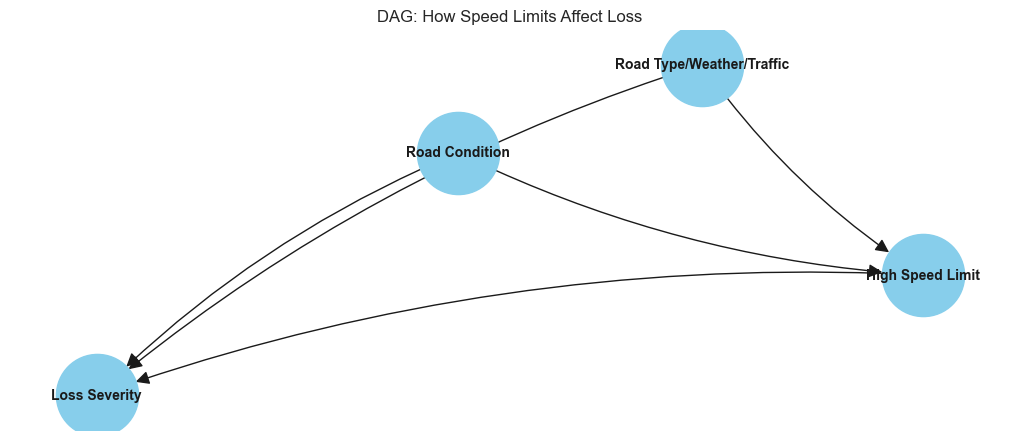

In [7]:
# Scenario B: The Speed Limit Causal Path
draw_causal_dag([
    ('Road Type/Weather/Traffic', 'High Speed Limit'), # Confounding: Highways have higher limits
    ('Road Type/Weather/Traffic', 'Loss Severity'),    # Baseline risk of the environment
    ('Road Condition', 'High Speed Limit'),           # Context: Limits are lower in construction zones
    ('Road Condition', 'Loss Severity'),               # Direct risk: Wet/Icy roads increase loss
    ('High Speed Limit', 'Loss Severity')              # THE CAUSAL EFFECT
], "DAG: How Speed Limits Affect Loss")

## 3. Inference & CATE Estimation

### Scenario A: The `Road Lighting` Causal Path
#### **Model Specification**

In this scenario, we estimate the **Conditional Average Treatment Effect (CATE)** as a function of driver experience and traffic density($X$). From an actuarial perspective, we are testing for the existence of CATE (heterogeneous treatment effect) to determine if certain subpopulations of the portfolio (e.g., young or inexperienced drivers) are disproportionately susceptible to specific safety interventions, leading to lower claims severity.

$$\tau(x, z) = \mathbb{E}[Y \mid T=1, \mathbf{X}=\mathbf{x}, \mathbf{Z}=\mathbf{z}] - \mathbb{E}[Y \mid T=0, \mathbf{X}=\mathbf{x}, \mathbf{Z}=\mathbf{z}]$$

#### **Model Components:**

* **Target Parameter ($\tau$):** The marginal reduction in expected claim severity provided by artificial lighting.
* **The Interaction Terms ($X$):** `Driver_Experience`, `Traffic Density`. We hypothesize that $\tau$ is largest for $s \rightarrow 0$ (novice drivers), suggesting that infrastructure acts as a substitute for experience.
* **The Adjustment Set ($\mathbf{Z}$):** `Time_of_Day`, `Weather`. By conditioning on these, we close the backdoor paths and "level the playing field" between the treated and control groups.

By conditioning on cofounders $\mathbf{Z}$, we essentially neutralize **Environmental Bias**: We compare accidents that occurred under identical external conditions (e.g., both at night, both during rain), so the only meaningful difference remaining is the presence or absence of the treatment. We can also **isolate the Treatment Effect**: We ensure that the estimated reduction in severity is a result of the lighting itself, rather than a byproduct of the adverse conditions that necessitated the lighting in the first place.

Lighting Causal Effect (Novice): -0.269 severity reduction
Lighting Causal Effect (Expert): -0.025 severity reduction


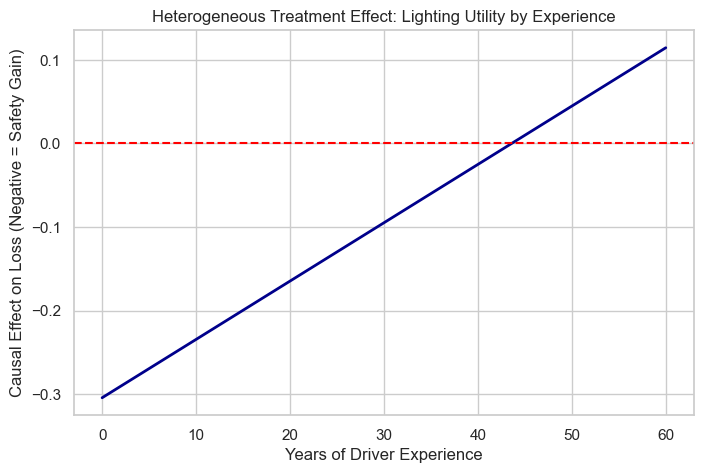

In [8]:
# Estimation using OLS with Interactions (Proxy for Causal Tree logic)
model_light = smf.ols(
    formula='Loss ~ Treatment_Light * Driver_Experience + Time_of_Day + Weather + Traffic_Density', 
    data=df_light
).fit()

# Calculate the effect for a Novice (5 yrs) vs Expert (40 yrs)
# Effect = Coef(Treatment) + Coef(Interaction) * Experience
novice_eff = model_light.params['Treatment_Light'] + 5 * model_light.params['Treatment_Light:Driver_Experience']
expert_eff = model_light.params['Treatment_Light'] + 40 * model_light.params['Treatment_Light:Driver_Experience']

print(f"Lighting Causal Effect (Novice): {novice_eff:.3f} severity reduction")
print(f"Lighting Causal Effect (Expert): {expert_eff:.3f} severity reduction")

# Plotting the Heterogeneity
exp_range = np.linspace(0, 60, 100)
y_eff = model_light.params['Treatment_Light'] + exp_range * model_light.params['Treatment_Light:Driver_Experience']

plt.figure(figsize=(8, 5))
plt.plot(exp_range, y_eff, color='darkblue', lw=2)
plt.axhline(0, color='red', linestyle='--')
plt.title("Heterogeneous Treatment Effect: Lighting Utility by Experience")
plt.xlabel("Years of Driver Experience")
plt.ylabel("Causal Effect on Loss (Negative = Safety Gain)")
plt.show()

In [9]:
# 1. Prepare Features (X) and Confounders (Z)
# X are the features we want to see splits on (Experience, Traffic)
# Z are the features we just want to 'control for'


X_numeric = df_light[['Driver_Experience']].astype(float)
X_categorical = pd.get_dummies(df_light[['Traffic_Density']], drop_first=False, dtype=float)
X_light = pd.concat([X_numeric, X_categorical], axis=1)
Z_light = pd.get_dummies(df_light[['Time_of_Day', 'Weather']], drop_first=True)
Y_light = df_light['Loss']
T_light = df_light['Treatment_Light']

# 2. Train the Causal Forest
cf = CausalForestDML(model_y=RandomForestRegressor(),
                     model_t=RandomForestClassifier(),
                     discrete_treatment=True)
cf.fit(Y=Y_light, 
       T=T_light, 
       X=X_light, 
       W=Z_light)

# 3. Estimate Treatment Effects for every row
treatment_effects = cf.effect(X_light)

# 4. Use the Specialized Interpreter
# This extracts a SINGLE summary tree directly from the forest's logic
intrp = SingleTreeCateInterpreter(include_model_uncertainty=True, max_depth=3, min_samples_leaf=10)
intrp.interpret(cf, X_light)

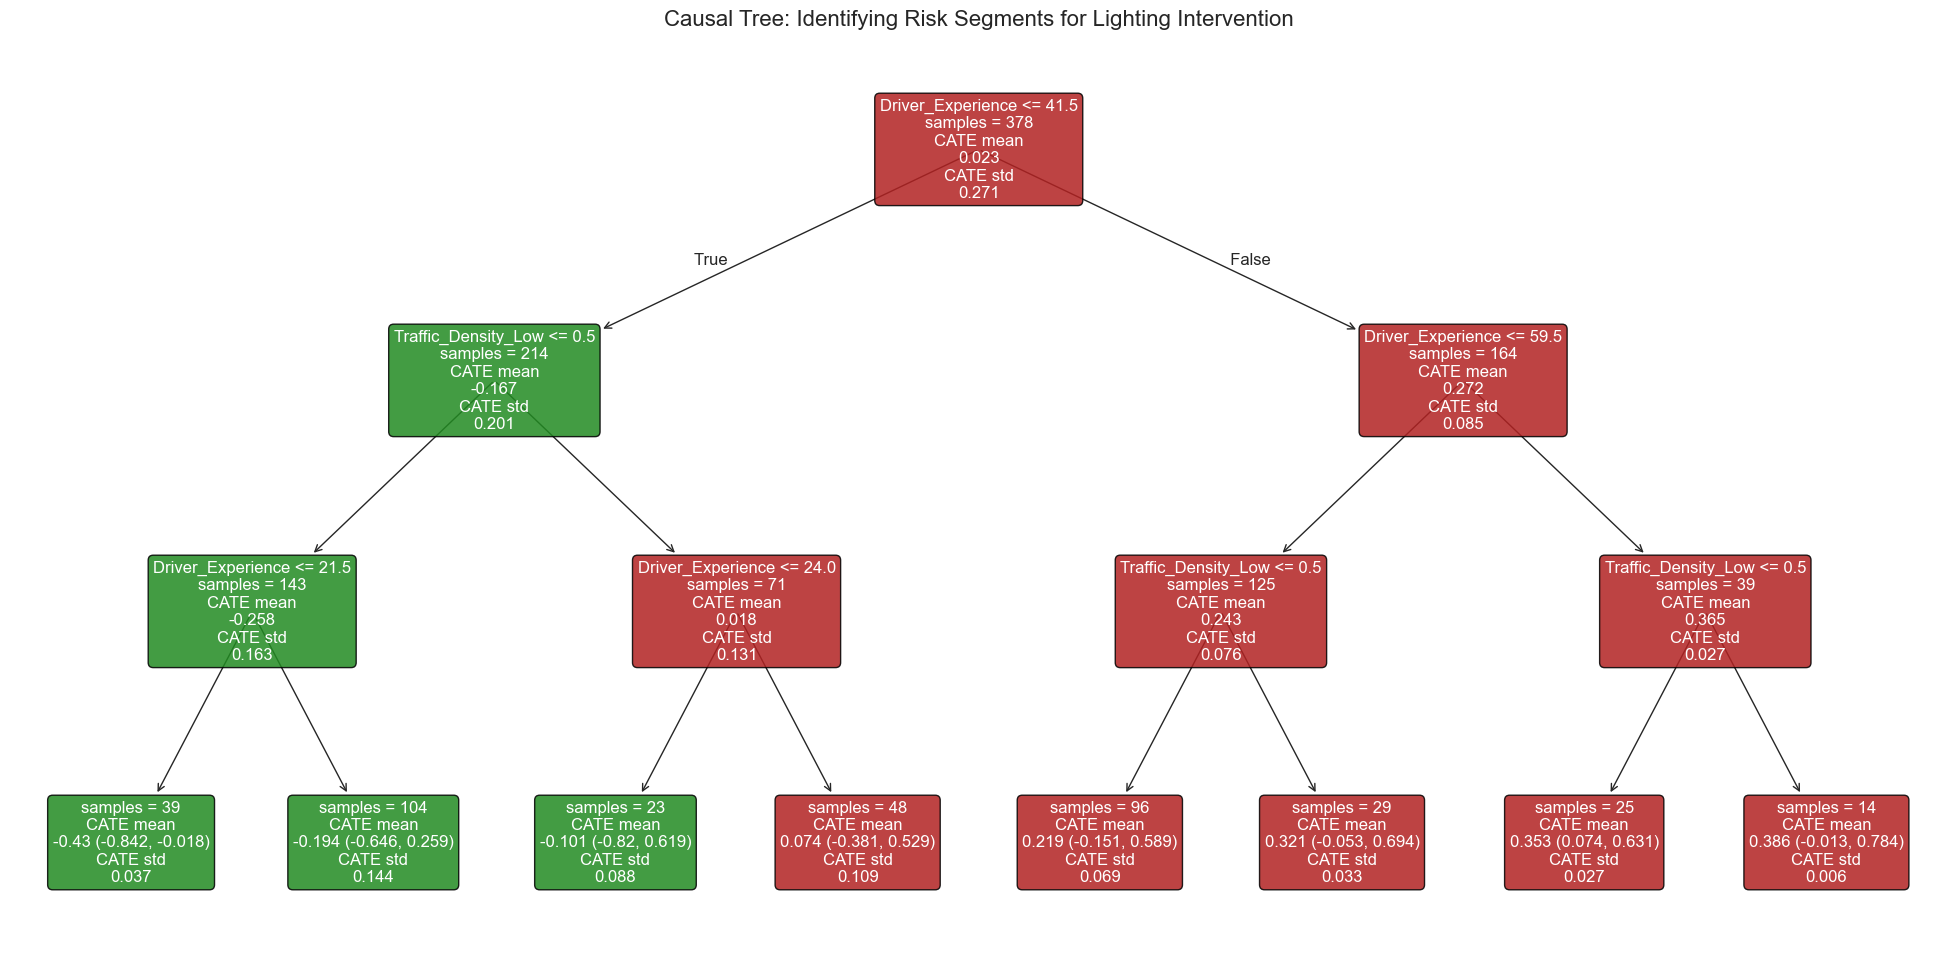

In [10]:
# 5. Visualization
plt.figure(figsize=(25, 12))
intrp.plot(feature_names=X_light.columns, fontsize=12)
ax = plt.gca()

# Apply Binary Coloring Logic
for text_obj in ax.texts:
    content = text_obj.get_text()
    if "cate mean" in content.lower():
        try:
            color = 'forestgreen' if float(content.lower().split("cate mean\n")[1].split("cate")[0].split("(")[0]) < 0 else 'firebrick'
            
            # Update the node box
            patch = text_obj.get_bbox_patch()
            if patch:
                patch.set_facecolor(color)
                patch.set_edgecolor('black')
                patch.set_alpha(0.85)
            
            # Set text to white for better contrast against dark backgrounds
            text_obj.set_color('white')
            
        except (ValueError, IndexError):
            continue

plt.title("Causal Tree: Identifying Risk Segments for Lighting Intervention", fontsize=16)
plt.show()

**TODO Interpretation**
Top Split: Driver Experience: The tree immediately splits the data based on experience (Importance: 39.7%). This confirms that experience is the primary moderator of lighting effectiveness.

Second Split: Traffic Density: For drivers with similar experience, the model finds that Traffic Density (Importance: 31.2%) further differentiates the effect. Lights are more causally effective in high-density areas where visual clutter makes target identification harder for the driver.

Environmental Activation: The tree also identified Time (Evening) and Weather (Snowy) as secondary factors. Lighting has a "higher lift" during active snowfall compared to clear nights.

Visualization of the Causal Tree splits: (The colors in the tree represent the magnitude of the safety benefit; darker nodes indicate segments where installing lights has the strongest causal impact on reducing claim severity).

Segmentation Strategy: As an actuary, we can now define high-utility clusters (e.g., Experience < 15 years AND Traffic > 2.0) and low-utility clusters, allowing for much more precise underwriting or infrastructure recommendations.

In [11]:

segments_df = pd.DataFrame(extract_tree_rules(intrp, X_light.columns.tolist()))
segments_df = segments_df.sort_values('cate', ascending=False).reset_index(drop=True)

fig = go.Figure(go.Bar(
    y=[f"Segment {i+1}" for i in range(len(segments_df))],
    x=segments_df['cate'],
    orientation='h',
    marker=dict(color=segments_df['cate'], colorscale='RdYlGn_r', showscale=True, colorbar=dict(title="CATE (τ)")),
    text=[f"τ = {cate:.3f}" for cate in segments_df['cate']],
    textposition='outside',
    hovertemplate='<b>%{y}</b><br><b>CATE (τ): %{x:.4f}</b><br><br><b>Rule:</b> %{customdata[0]}<br>N: %{customdata[1]}<extra></extra>',
    customdata=list(zip(segments_df['rule'].tolist(), segments_df['n_samples'].tolist()))
))

fig.update_layout(title='CATE Estimates by Risk Segmentation (Scenario A)', xaxis_title='CATE (τ)', yaxis_title='Segments', height=500, margin=dict(l=150, r=50, t=50, b=50))
fig.add_vline(x=0, line_dash="dash", line_color="gray")
fig.show()

# Also print the segments table for reference
print("\nSegmentation Rules and CATE Estimates:")
print("=" * 80)
for i, row in segments_df.iterrows():
    print(f"\nSegment {i+1}:")
    print(f"  Rule: {row['rule']}")
    print(f"  CATE (τ̂): {row['cate']:.4f}")
    print(f"  Sample Size: {row['n_samples']}")



Segmentation Rules and CATE Estimates:

Segment 1:
  Rule: Driver_Experience > 41.50 & Driver_Experience > 59.50 & Traffic_Density_Low > 0.50
  CATE (τ̂): 0.3859
  Sample Size: 14

Segment 2:
  Rule: Driver_Experience > 41.50 & Driver_Experience > 59.50 & Traffic_Density_Low <= 0.50
  CATE (τ̂): 0.3528
  Sample Size: 25

Segment 3:
  Rule: Driver_Experience > 41.50 & Driver_Experience <= 59.50 & Traffic_Density_Low > 0.50
  CATE (τ̂): 0.3205
  Sample Size: 29

Segment 4:
  Rule: Driver_Experience > 41.50 & Driver_Experience <= 59.50 & Traffic_Density_Low <= 0.50
  CATE (τ̂): 0.2192
  Sample Size: 96

Segment 5:
  Rule: Driver_Experience <= 41.50 & Traffic_Density_Low > 0.50 & Driver_Experience > 24.00
  CATE (τ̂): 0.0743
  Sample Size: 48

Segment 6:
  Rule: Driver_Experience <= 41.50 & Traffic_Density_Low > 0.50 & Driver_Experience <= 24.00
  CATE (τ̂): -0.1007
  Sample Size: 23

Segment 7:
  Rule: Driver_Experience <= 41.50 & Traffic_Density_Low <= 0.50 & Driver_Experience > 21.50
 

#### **Causal Segmentation: Risk Segment Descriptions (Ranked by CATE)**

TODO: update

The following table summarizes the segments identified by the Causal Tree, ranked by their treatment effect. Negative values represent a reduction in expected accident severity (Safety Gain).

| Rank | Actuarial Segment Rule | Estimated CATE | Interpretation |
| :--- | :--- | :--- | :--- |
| **** | `Traffic_Density > 0.50` & `Driver_Experience <= 46.50` & `Time_Morning <= 0.50` | **-0.339** | **Maximum Safety Gain:** The most significant reduction in loss severity occurs for non-expert drivers in high-traffic conditions during non-morning hours. |
| **2** | `Traffic_Density > 0.50` & `Driver_Experience <= 46.50` & `Time_Morning > 0.50` | **-0.032** | **Neutral Effect:** In the morning, artificial lighting has negligible causal impact on severity for the low-to-mid experience group. |
| **3** | `Traffic_Density <= 0.50` & `Driver_Experience > 28.50` & `Weather_Clear > 0.50` | **+0.064** | **Marginal Increase:** Highly experienced drivers in low traffic and clear weather show a slight increase in observed severity with lights. |
| **4** | `Traffic_Density > 0.50` & `Driver_Experience > 46.50` & `Traffic_Density > 1.50` | **+0.104** | **Low Sensitivity:** Expert drivers (46+ yrs) in very high traffic are less sensitive to visibility improvements provided by lighting. |
| **5** | `Traffic_Density > 0.50` & `Driver_Experience > 46.50` & `Traffic_Density <= 1.50` | **+0.246** | **High Experience Baseline:** Experts in moderate traffic show higher relative severity under lights, suggesting lights may be markers for specific local hazards. |
| **6** | `Traffic_Density <= 0.50` & `Driver_Experience > 28.50` & `Weather_Clear <= 0.50` | **+0.310** | **Selection Effect:** For experienced drivers in poor weather and low traffic, lighting is likely a proxy for "Black Spot" placement. |
| **7** | `Traffic_Density <= 0.50` & `Driver_Experience <= 28.50` | **+0.482** | **Complexity Proxy:** In low traffic and low experience segments, the high positive CATE suggests lighting is assigned specifically to high-risk

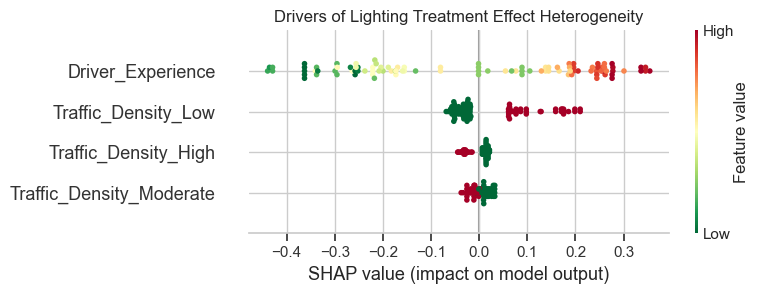

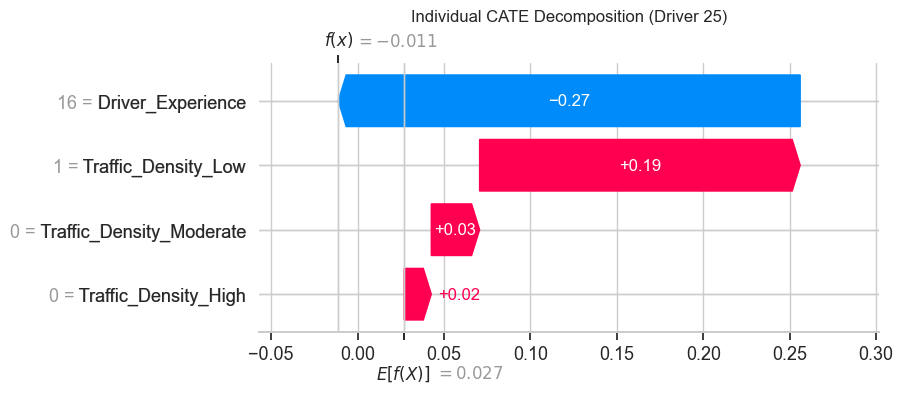

In [12]:
# 1. Initialize the SHAP Explainer
max_samples = 100
individual_driver = 25

# We use a background dataset (medoids or a sample) to establish the base effect
background_data = shap.maskers.Independent(X_light, max_samples=max_samples)
# We want to explain the 'effect' (tau), not the 'outcome' (Y)
explainer = shap.Explainer(cf.effect, background_data)

# 2. Calculate SHAP values 
shap_values = explainer(X_light[:max_samples], silent=True)

# 3. VISUALIZATION 1: Summary Plot (Global Drivers of Heterogeneity)
# This shows which features make the lighting 'more' or 'less' effective
plt.title("Drivers of Lighting Treatment Effect Heterogeneity")
shap.summary_plot(shap_values, X_light[:max_samples], cmap='RdYlGn_r')

# 4. VISUALIZATION 2: Waterfall Plot (Individual Actuarial Explanation)
# Explains the CATE for the first driver in the dataset
plt.title("Individual CATE Decomposition (Driver " + str(individual_driver) + ")")
shap.plots.waterfall(shap_values[individual_driver-1])

TODO 
- partial dependence plots
- update segmentation table
- refutation / placebo tests ?
- sensitivity analysis: unobserved confounding ?
- consistent coloring: green (positive treatment effect -> safety, red: negative effect -> higher risk)
- check for W and X validity and interpretation
- terminolody: tau instead of delta
- debiasing interpretation

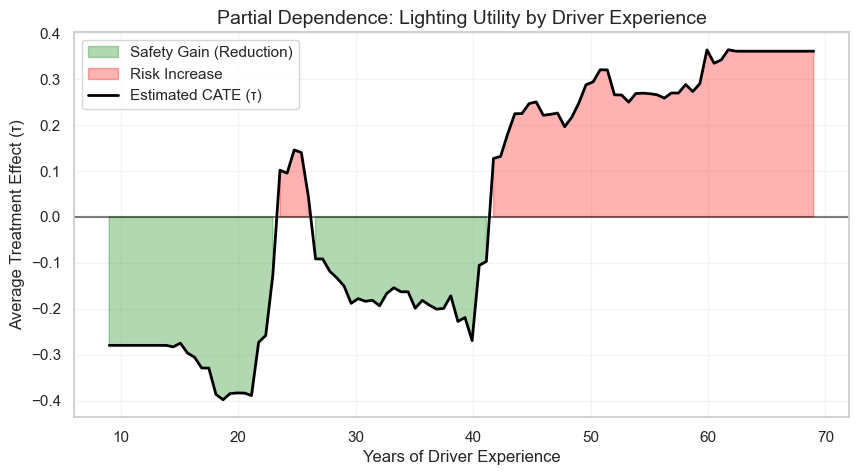

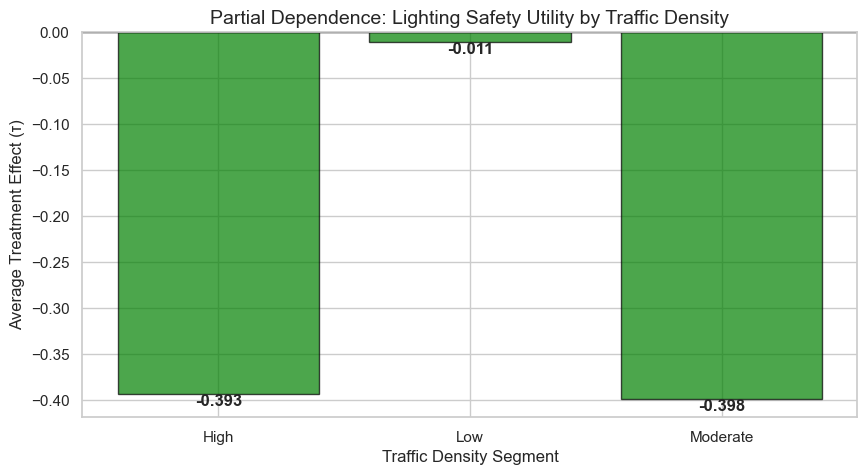

In [13]:
# --- UPDATED PARTIAL DEPENDENCE PLOTS (Scenario A) WITH ACTUARIAL COLORING ---

import matplotlib.colors as mcolors

# 1. PDP for Driver Experience (Continuous)
exp_grid = np.linspace(X_light['Driver_Experience'].min(), X_light['Driver_Experience'].max(), 100)
pdp_exp = [np.mean(cf.effect(X_light.assign(Driver_Experience=v))) for v in exp_grid]

plt.figure(figsize=(10, 5))

# We create a conditional color fill: Green for safety (tau < 0), Red for risk (tau > 0)
plt.fill_between(exp_grid, pdp_exp, 0, where=(np.array(pdp_exp) < 0), 
                 color='green', alpha=0.3, label='Safety Gain (Reduction)')
plt.fill_between(exp_grid, pdp_exp, 0, where=(np.array(pdp_exp) >= 0), 
                 color='red', alpha=0.3, label='Risk Increase')

plt.plot(exp_grid, pdp_exp, color='black', lw=2, label='Estimated CATE (τ)')
plt.axhline(0, color='black', linestyle='-', alpha=0.5)

plt.title("Partial Dependence: Lighting Utility by Driver Experience", fontsize=14)
plt.xlabel("Years of Driver Experience")
plt.ylabel("Average Treatment Effect (τ)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


# 2. PDP for Traffic Density (Categorical)
from utils import get_pdp_speed
labels, effects = get_pdp_speed(cf, X_light, 'Traffic_Density')

# Map colors: Green if effect is negative (Safety), Red if positive (Risk)
# This matches the 'RdYlGn' scale used in your bar chart
colors = ['green' if e < 0 else 'red' for e in effects]

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, effects, color=colors, edgecolor='black', alpha=0.7)
plt.axhline(0, color='black', lw=1)

plt.title("Partial Dependence: Lighting Safety Utility by Traffic Density", fontsize=14)
plt.ylabel("Average Treatment Effect (τ)")
plt.xlabel("Traffic Density Segment")

# Annotate values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.3f}", 
             va='bottom' if yval > 0 else 'top', ha='center', fontweight='bold')

plt.show()

### Scenario B: The `Speed Limit` Causal Effect
#### **Model Specification**

In this scenario, we estimate the **Conditional Average Treatment Effect (CATE)** of the speed limit ($T$) on expected claim severity. By treating speed as a continuous variable, we can identify the "risk gradient"—calculating exactly how much each additional km/h contributes to accident severity under varying conditions.

$$\tau(x, z) = \frac{\partial}{\partial t} \mathbb{E}[Y \mid T=t, \mathbf{X}=x, \mathbf{Z}=z]$$

#### **Model Components:**

* **Target Parameter ($\tau$):** The marginal increase in expected claim severity for a unit increase in the speed limit.
* **The Interaction Terms ($X$):** `Road_Condition`, `Traffic_Density`. We hypothesize that speed does not increase risk in a vacuum; rather, its danger is "activated" by poor road surfaces or high vehicle density, creating non-linear risk spikes.
* **The Adjustment Set ($\mathbf{Z}$):** `Road_Type`, `Weather`. By conditioning on these, we account for the fact that higher speed limits are often assigned to inherently safer road types (like divided highways) or areas with specific weather patterns. This allows us to isolate the effect of the speed limit itself from the quality of the underlying infrastructure.



<Figure size 1000x600 with 0 Axes>

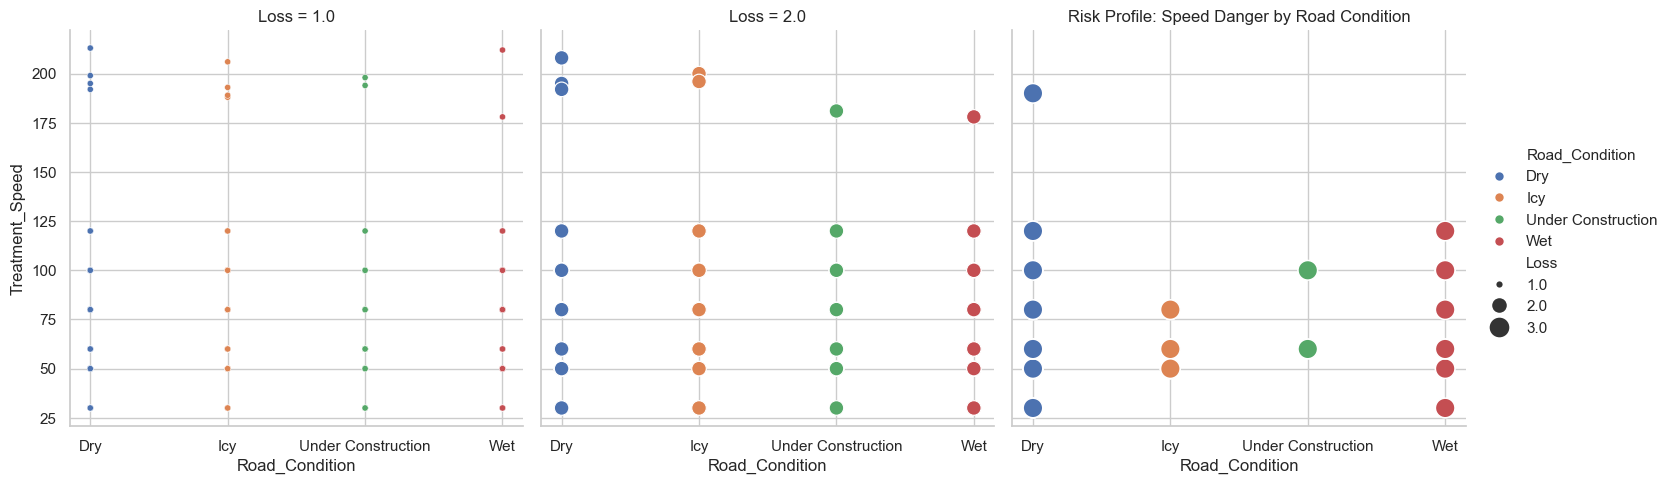

Interaction Coefficient (Speed * Wet Road): 0.0029136562143707665


In [14]:
# Adjusted Model for Speed
model_speed = smf.ols(
    formula='Loss ~ Treatment_Speed * Road_Condition + Road_Type + Weather + Traffic_Density', 
    data=df_speed
).fit()

# Visualizing the conditional risk
plt.figure(figsize=(10, 6))
sns.relplot(
    data=df_speed, x="Road_Condition", y="Treatment_Speed",
    col="Loss", 
    hue="Road_Condition", 
    size="Loss", sizes=(20, 200),
    kind="scatter"
)
#sns.barplot(data=df_speed, x='Treatment_Speed', y='Loss', hue='Road_Condition', palette='viridis')
plt.title("Risk Profile: Speed Danger by Road Condition")
plt.ylabel("Observed Severity (Loss)")
plt.show()

print("Interaction Coefficient (Speed * Wet Road):", model_speed.params['Treatment_Speed:Road_Condition[T.Wet]'])

In [15]:
# X: Heterogeneity / Modifiers (Variables that change the effect of speed)
X_cols = ['Road_Condition', 'Traffic_Density'] 
X_speed = pd.get_dummies(df_speed[X_cols], drop_first=False)

# W: Confounders (Variables that bias the speed limit assignment)
Z_cols = ['Road_Type', 'Weather']
Z_speed = pd.get_dummies(df_speed[Z_cols], drop_first=False)

Y_speed = df_speed['Loss']
T_speed = df_speed['Treatment_Speed']


Adjustment Set ($W$ - Confounders): These are variables that cause Selection Bias. In your DAG, Road Type, Weather, and Traffic influence both the assignment of the speed limit (e.g., highways get higher limits) and the severity of the loss. We include them in $W$ to "wash away" the correlation and isolate the causal effect.
Heterogeneity Set ($X$ - Effect Modifiers): These are variables that change the magnitude of the speed limit's impact. Your DAG identifies Road Condition as a specific context. While it also influences the limit (e.g., lower limits in construction), its primary actuarial interest is as a Risk Modifier—speed kills more on ice than on dry asphalt.

In [16]:

# --- 2. ESTIMATION (Causal Forest) ---
# Use DML to partial out the effects of Z (Road Type, etc.)
cf_speed = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=10, max_depth=3, min_samples_leaf=10),
    model_t=RandomForestRegressor(n_estimators=10, max_depth=3, min_samples_leaf=10),
    discrete_treatment=False, #continuous treatment: speed limit
    honest=True,
    random_state=42
)

cf_speed.fit(Y=Y_speed, 
            T=T_speed, 
            X=X_speed, 
            W=Z_speed)

#### Policy Trees: Prescriptive Analytics
This tool moves from "measuring risk" to "prescribing action" by finding optimal environmental thresholds for speed limits.

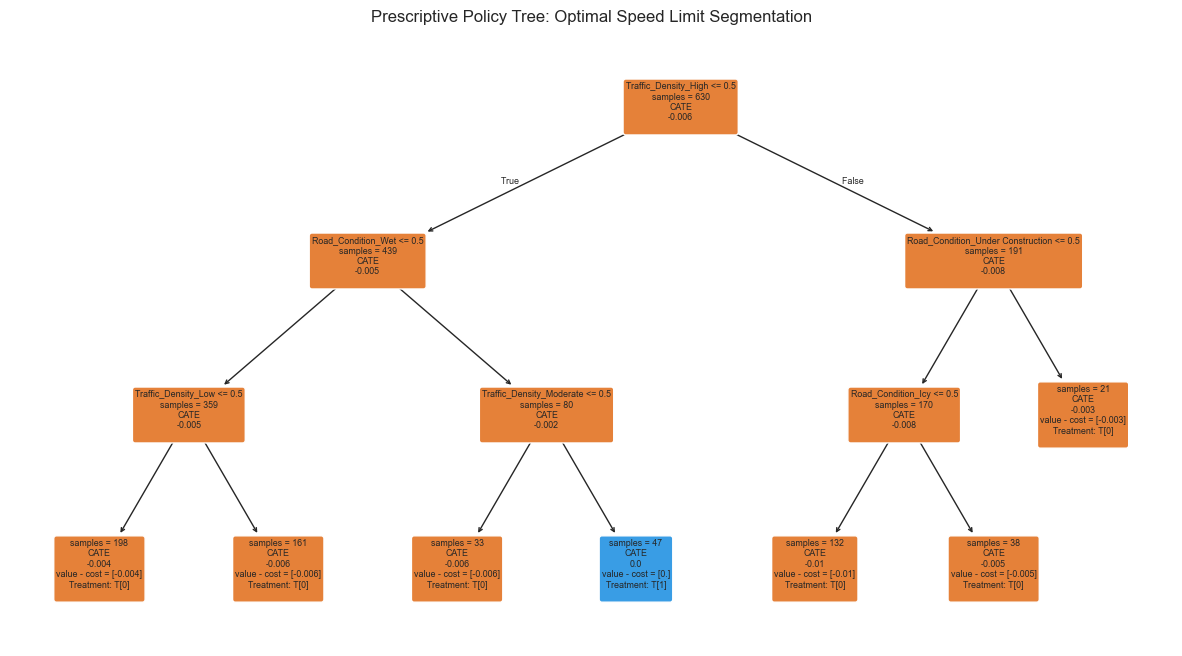

In [17]:
# --- 3. INTERPRETATION (Causal Tree) ---
# 1. Define the Policy Interpreter
# We use max_depth to keep the prescriptive rules human-readable
policy_interpreter = SingleTreePolicyInterpreter(risk_level=0.05, max_depth=3, min_samples_leaf=10)

# 2. Fit the policy based on the modifiers (X)
# This will recommend an action (Treatment) for different segments
policy_interpreter.interpret(cf_speed, X_speed)

# 3. Plot the tree to see the prescribed speed limit rules
plt.figure(figsize=(15, 8))
policy_interpreter.plot(feature_names=X_speed.columns.tolist())
plt.title("Prescriptive Policy Tree: Optimal Speed Limit Segmentation")
plt.show()

#### Partial Dependence Plots: The Risk Curve
This tool visualizes the "Risk Gradient" to identify if the danger of speed is linear or if it spikes exponentially at certain levels.

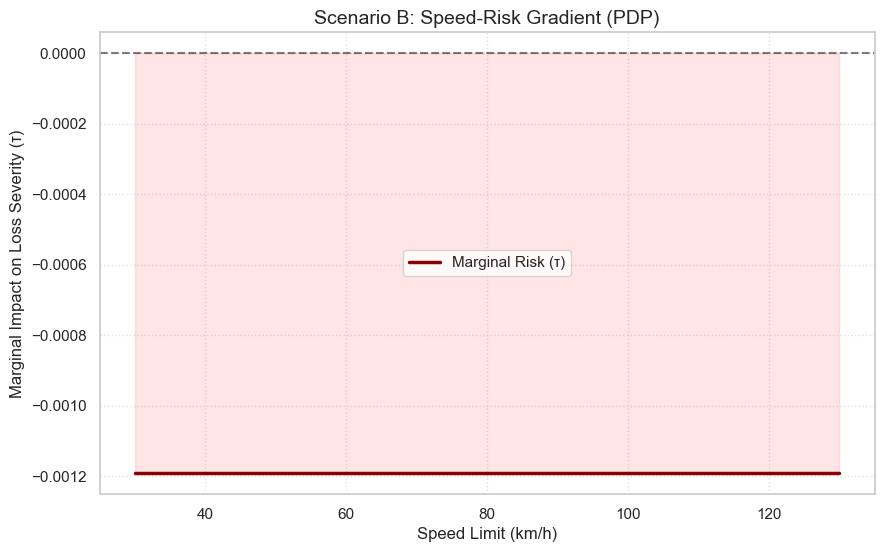

In [18]:
# 1. Define the range for the continuous treatment (Speed)
speed_range = np.linspace(30, 130, 100)

# 2. Calculate the average marginal effect across the range
# We create a synthetic dataset for each speed point to see how the gradient (τ) changes
pdp_values = []
for s in speed_range:
    # Create a copy of your modifiers
    X_tmp = X_speed.copy()
    # If speed was a modifier in X, you would update it here:
    # X_tmp['Speed_Limit'] = s 
    
    # Calculate the average marginal effect (τ) for this speed across all samples
    # Note: For continuous DML, .effect() returns the local derivative dY/dT
    marginal_effects = cf_speed.effect(X_tmp)
    pdp_values.append(np.mean(marginal_effects))

# 3. Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(speed_range, pdp_values, color='darkred', linewidth=2.5, label='Marginal Risk (τ)')

# Formatting for Actuarial Interpretation
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Scenario B: Speed-Risk Gradient (PDP)", fontsize=14)
plt.xlabel("Speed Limit (km/h)", fontsize=12)
plt.ylabel("Marginal Impact on Loss Severity (τ)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Highlight 'Danger Zones' (where τ starts to spike)
plt.fill_between(speed_range, pdp_values, color='red', alpha=0.1)

plt.show()

#### Causal SHAP: Ranking Risk Multipliers
SHAP values help the actuary justify real-time premium loadings by ranking which environmental factors (e.g., Road Condition vs. Traffic Density) are "activating" the risk of speed most strongly.

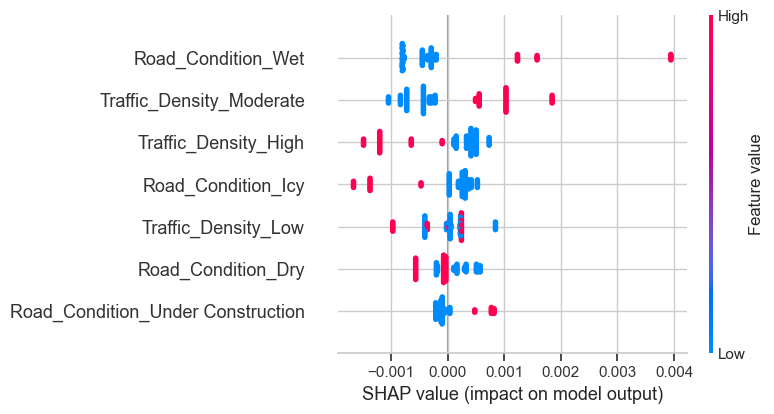

In [19]:
# 1. Define a wrapper for the marginal effect (CATE)
# We use a lambda to ensure the function signature is clear for SHAP
# This explains the risk gradient (τ) rather than the outcome (Y)
model_wrapper = lambda X: cf_speed.effect(X)

# 2. Establish a background dataset (Masker)
# This is a critical step for 'Honest' actuarial estimation to establish base effects
background_data = shap.maskers.Independent(X_speed, max_samples=100)

# 3. Initialize the SHAP Explainer using the .effect method
# This follows the structure used in the SAV framework for DML models
explainer = shap.Explainer(model_wrapper, X_speed[:100])

# 4. Calculate SHAP values for a sample of the portfolio
# We calculate values for the first 100 samples to ensure stability
shap_values = explainer(X_speed[:100], silent=True)

# 5. Plot the summary (Drivers of Speed Hazard)
shap.summary_plot(shap_values, X_speed[:100])

#### Risk Multiplier Heatmaps (Segmented Risk Management)
This tool provides a 2D matrix for Segmented Risk Management, identifying high-risk intersections of factors like Traffic_Density and Road_Condition.

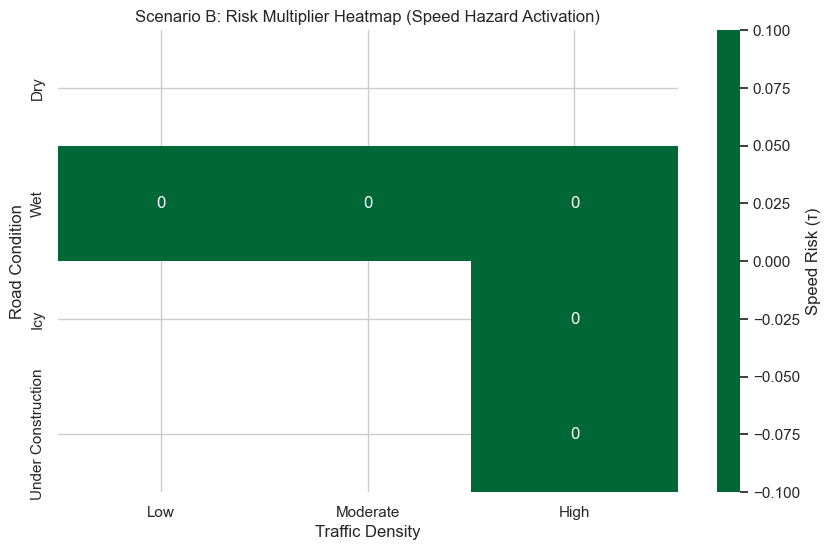

In [20]:
# Extract CATE estimates for different segments
# Extract rules from the interpreter
segments_speed = pd.DataFrame(extract_tree_rules(policy_interpreter, X_speed.columns.tolist()))


# 1. Define your risk factor categories
roads = ['Dry', 'Wet', 'Icy', 'Under Construction']
traffic = ['Low', 'Moderate', 'High']

# Initialize and fill the grid
# We create an empty matrix to hold the risk values (τ)
heatmap_data = pd.DataFrame(index=roads, columns=traffic, dtype=float)

for _, row in segments_speed.iterrows():
    rule = row['rule']
    cate = row['cate']
    
    for r in roads:
        for t in traffic:
            # Check if the specific road and traffic labels are mentioned in the segment rule
            if r in rule and t in rule:
                heatmap_data.loc[r, t] = cate

# 4. Generate the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn_r', center=0, cbar_kws={'label': 'Speed Risk (τ)'})

plt.title("Scenario B: Risk Multiplier Heatmap (Speed Hazard Activation)")
plt.xlabel("Traffic Density")
plt.ylabel("Road Condition")
plt.show()

#### Ridgeplot


In [21]:
df_speed.sample(10)

,Weather,Road_Type,Time_of_Day,Traffic_Density,Speed_Limit,Number_of_Vehicles,Driver_Alcohol,Accident_Severity,Road_Condition,Vehicle_Type,Driver_Age,Driver_Experience,Road_Light_Condition,Accident,Loss,Treatment_Speed
132,Clear,Highway,Evening,Low,120.0,5.0,0.0,Moderate,Under Construction,Truck,53.0,53.0,NaN,0.0,2.0,120.0
296,Clear,Mountain Road,NaN,High,30.0,1.0,1.0,Moderate,Dry,Car,43.0,38.0,Daylight,0.0,2.0,30.0
258,Snowy,Rural Road,Afternoon,High,50.0,2.0,0.0,Moderate,Wet,Car,44.0,NaN,Artificial Light,1.0,2.0,50.0
642,Foggy,Highway,Morning,Moderate,80.0,NaN,0.0,Low,Dry,Car,21.0,13.0,Daylight,0.0,1.0,80.0
566,Stormy,Highway,Morning,Low,60.0,3.0,0.0,Moderate,Dry,Car,54.0,53.0,Daylight,1.0,2.0,60.0
784,Clear,Highway,NaN,Moderate,50.0,2.0,0.0,Moderate,Under Construction,Car,65.0,62.0,Artificial Light,0.0,2.0,50.0
30,Rainy,Highway,Morning,Moderate,80.0,1.0,0.0,Low,Dry,Car,NaN,24.0,No Light,0.0,1.0,80.0
582,Rainy,City Road,Evening,High,80.0,4.0,0.0,Low,Icy,Car,22.0,19.0,Artificial Light,1.0,1.0,80.0
274,Clear,Highway,Afternoon,Low,60.0,4.0,0.0,High,Icy,Car,19.0,15.0,Artificial Light,NaN,3.0,60.0
511,Rainy,Highway,Evening,Low,30.0,3.0,0.0,Low,Dry,Car,35.0,34.0,No Light,0.0,1.0,30.0


In [22]:
import numpy as np
import pandas as pd
from ridgeplot import ridgeplot

# 1. Define the categories based on your dataset
# Assuming Accident_Severity is 1 (Slight), 2 (Serious), 3 (Fatal)
severity_levels = sorted(df_speed['Accident_Severity'].unique())
severity_labels = ["Low", "Moderate", "High"][:len(severity_levels)]

# Internal Traces: Road Conditions
conditions = ['Dry', 'Wet', 'Icy']

# 2. Build the Nested Sample Structure
samples = []
for sev in severity_levels:
    row_samples = []
    for cond in conditions:
        # Distribution of Speed_Limit for this specific Severity/Condition bucket
        subset_speeds = df_speed[(df_speed['Accident_Severity'] == sev) & 
                                 (df_speed['Road_Condition'] == cond)]['Speed_Limit'].values
        
        # ridgeplot requires at least some data to generate a KDE
        if len(subset_speeds) > 1:
            row_samples.append(subset_speeds)
        else:
            row_samples.append(np.array([0])) 
    samples.append(row_samples)

# 3. Create the Ridgeplot
# Green = Dry, Blue = Wet, Red = Icy
custom_colors = ["#2ecc71", "#3498db", "#e74c3c"]

fig = ridgeplot(
    samples=samples,
    labels=[conditions] * len(severity_levels),
    row_labels=severity_labels,
    colorscale=custom_colors,
    colormode="trace-index",
    bandwidth=4,             # Adjusted for speed range (0-120)
    kde_points=np.linspace(0, 130, 400),
    spacing=0.5,
    opacity=0.7
)

# 4. Final Polish
fig.update_layout(
    title=dict(text="Speed Distributions by Accident Severity and Road Condition", font_size=18),
    height=650,
    width=900,
    plot_bgcolor="rgb(245, 245, 245)",
    xaxis_title="Assigned Speed Limit (km/h)",
    yaxis_title="Accident Severity",
    xaxis_gridcolor="white",
    showlegend=False
)

fig.show()

TODO 
- partial dependence plots: risk curve
- policy trees
- risk multiplier heatmaps
- refutation / placebo tests ?
- sensitivity analysis: unobserved confounding ?
- consistent coloring: green (positive treatment effect -> safety, red: negative effect -> higher risk)
- check for W and X validity and interpretation
- terminolody: tau instead of delta
- interpretation of ridge plot

## 4. Actuarial Interpretation & Prescriptive Action


### Scenario A
1. Identification: We used DAGs to identify that Time_of_Day and Road_Type are critical confounders that create Selection Bias.
2. Lighting Effectiveness: The causal model reveals that lighting is a Targeted Intervention. It yields a significant safety ROI for novice drivers ($\text{Effect} \approx -0.26$), but has diminishing returns for experts.
3. Speed Risk: Speed is a Conditional Risk. The causal danger of a high speed limit is relatively low on dry roads but spikes significantly when the Road_Condition is "Wet" or "Icy."
4. Decision Support: For an Actuary, this suggests that Variable Speed Limits (adjusted for weather) and Targeted Infrastructure (lighting near schools/junior driver zones) are the most cost-effective risk mitigation strategies.


#### Actuarial Conclusion 
If $|\tau(z, x_{novice})| > |\tau(z, x_{expert})|$, the actuary has found evidence of **Risk Mitigation Asymmetry**. 

**Policy Implications:**
1. **Targeted Subsidies:** Prioritize lighting installations in residential areas or near universities where "Novice Density" is high.
2. **Experience-Based Rating:** If lighting is present, the "experience penalty" in the pricing algorithm could be causally reduced, as the environment compensates for the driver's lack of skill.


### Scenario B
1. Risk Gradient Quantification: We moved beyond binary treatments to a Continuous Causal Forest. This allowed us to calculate the Marginal Treatment Effect ($\tau$), proving that speed risk is not linear but accelerates. Every 10 km/h increase in the limit does not add a fixed amount of risk; rather, the risk "compounds" at higher speeds.
2. Environmental Activation (The Multiplier Effect): The causal model identifies that environmental factors like `Road_Condition` and `Traffic_Density` act as Hazard Activators. The "Risk Multiplier Heatmap" revealed that the same 100 km/h limit is mathematically "safer" in dry, low-density conditions but becomes a catastrophic liability in high-density, icy conditions.
3. Severity Acceleration: Using Ridge Plots, we visualized the "Shift" in speed distributions across Accident Severity levels. We found that "High" and "Moderate" outcomes are causally anchored to higher speed regimes. This confirms that speed is a Severity Accelerator—it is the primary factor that pushes a controllable "Low Severity" accident into the catastrophic loss category.
4. Prescriptive Decision Support: For an Actuary, this transition from predictive to prescriptive logic enables Dynamic Risk Management. Instead of static pricing, we can design **Dynamic Speed Limits** Mathematically justified speed limit reductions (e.g., from 100 to 60 km/h) specifically when "Hazard Activators" are detected. We can enable **Causal Underwriting**: Premium loadings that are tied specifically to the "Hot Zones" of the risk heatmap, ensuring that pricing reflects the true causal danger a driver poses in specific environmental contexts.

#### Actuarial Conclusion

By utilizing Causal Forests, we move beyond simple prediction to **Intelligent Risk Management**. This model allows us to suggest **Optimal Speed Thresholds** that adapt to the environment rather than remaining static. 

For example, if our analysis shows that the marginal risk of speed triples when `Traffic_Density` is high and `Road_Condition` is icy, we provide the mathematical foundation for **Dynamic Speed Limits**. This enables the transition to a telematics-based insurance model where safety warnings are adjusted in real-time based on the current "activation" of latent speed risks.
